In [4]:
import pandas as pd
import numpy as np
import re
import time
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import gzip


# --- 1. ROBUST PARSING & AGGREGATION ---
LOG_PATTERN = re.compile(r'(\S+) - - \[(.*?)\] "(.*?)" (\d{3}) (\S+)')

# --- HELPER FUNCTIONS ---
def build_tree_features(df):
    x = df.copy().sort_values(by="timestamp")
    #for lag in [1, 2, 24]:
    for lag in [1, 2]:
        x[f"lag_{lag}"] = x["request_count"].shift(lag)
    x["hour_sin"] = np.sin(2 * np.pi * x.index.hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * x.index.hour / 24)
    x["target"] = x["request_count"].shift(-1)
    return x.dropna()

def parse_line(line):
    m = LOG_PATTERN.match(line.strip())
    if not m: return None
    host, ts, req, status, size = m.groups()
    return {
        "timestamp": ts,
        "status": int(status),
        "bytes": 0 if size == "-" else int(size)
    }

def ingest_and_aggregate(file_path):
    print("Ingesting logs...")
    start_time = time.time()
    with gzip.open(file_path, "rt", encoding="latin-1") as f:
        df = pd.DataFrame([parse_line(l) for l in f if parse_line(l)])
    
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%b/%Y:%H:%M:%S %z", utc=True)
    hourly = df.set_index("timestamp").resample("1h").agg(
        request_count=("status", "count"),
        error_5xx=("status", lambda s: ((s >= 500) & (s < 600)).sum()),
        bytes_sum=("bytes", "sum")
    ).fillna(0)
    
    duration = time.time() - start_time
    print(f"Aggregation complete: {len(hourly)} hourly intervals. (Took {duration:.2f}s)")
    return hourly

def run_anomaly_detection(raw_data):
    """
    Uses Isolation Forest to detect unusual traffic spikes or error rates.
    """
    print("\n--- Starting Anomaly Detection ---")

    features = ["request_count", "error_5xx", "bytes_sum"]
    X = raw_data[features].copy()
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(contamination=0.05, random_state=42)
    X["anomaly_score"] = model.fit_predict(X_scaled)

    anomalies = X[X["anomaly_score"] == -1]
    print(f"Detected {len(anomalies)} anomalous hours out of {len(X)} total hours.")

    plt.figure(figsize=(15, 6))
    plt.plot(X.index, X["request_count"], color="blue", label="Normal Traffic", alpha=0.6)
    plt.scatter(anomalies.index, anomalies["request_count"], color="red", label="Anomalies", s=50)

    plt.title("Traffic Anomaly Detection (Isolation Forest)")
    plt.xlabel("Time")
    plt.ylabel("Request Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return model, anomalies


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# --- 3. DEEP LEARNING MODEL (LSTM) ---
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

def prepare_lstm_data(df, lookback=24):
    print("data preparation")
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    df_dl = df.copy()
    df_dl["hour_sin"] = np.sin(2 * np.pi * df_dl.index.hour / 24)
    df_dl["hour_cos"] = np.cos(2 * np.pi * df_dl.index.hour / 24)

    data_x = scaler_x.fit_transform(df_dl)
    data_y = scaler_y.fit_transform(df_dl[["request_count"]])
    print("prepare_lstm_data after scaling shapes:", data_x.shape, data_y.shape)

    x_list, y_list = [], []
    for i in range(len(data_x) - lookback):
        x_list.append(data_x[i:i+lookback])
        y_list.append(data_y[i+lookback])

    X = np.array(x_list)
    y = np.array(y_list)
    print("prepare_lstm_data returned", X.shape, y.shape)
    return X, y, scaler_x, scaler_y

def train_on_lstm(raw_df):

    # --- Part B: LSTM ---
    lookback = 24
    epoch = 100 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_num_threads(4)
    print("Using device:", device)

    X_l, y_l, scaler_x, scaler_y = prepare_lstm_data(raw_df, lookback)
    split = int(len(X_l) * 0.8)
    print("LSTM data shapes:", X_l.shape, y_l.shape, "split:", split)

    X_l_train_t = torch.FloatTensor(X_l[:split])
    y_l_train_t = torch.FloatTensor(y_l[:split])
    X_l_test = torch.FloatTensor(X_l[split:])
    y_l_test = torch.FloatTensor(y_l[split:])

    print("LSTModel Start")
    model = LSTMModel(input_dim=X_l.shape[2], hidden_dim=32, num_layers=1, output_dim=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    train_dataset = TensorDataset(X_l_train_t, y_l_train_t)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    model.train()
    for epoch_id in range(epoch):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
        epoch_loss /= len(train_dataset)
        print(f"epoch {epoch_id+1}/{epoch} loss={epoch_loss:.4f}")

    model.eval()
    with torch.no_grad():
        lstm_preds_norm = model(X_l_test.to(device)).cpu().numpy()
        lstm_preds = scaler_y.inverse_transform(lstm_preds_norm).flatten()
        actuals = scaler_y.inverse_transform(y_l_test.numpy()).flatten()


In [6]:
import joblib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

def calculate_advanced_metrics(y_true, y_pred):
    """
    Calculates comprehensive metrics for Cloud Scaling.
    Heavily penalizes under-prediction which causes downtime.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # Avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    # Infrastructure specific metrics (True = we predicted LESS than reality)
    under_predict_mask = y_pred < y_true
    under_predict_rate = np.mean(under_predict_mask)
    
    # Magnitude of under-prediction (The "Downtime Risk" in requests)
    under_errors = y_true[under_predict_mask] - y_pred[under_predict_mask]
    avg_under_error = np.mean(under_errors) if len(under_errors) > 0 else 0
    
    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE_%": round(mape, 2),
        "Under_Predict_Rate": round(under_predict_rate, 4),
        "Avg_Under_Error": round(avg_under_error, 2)
    }

def tune_xgboost(X, y):
    print("\n[ML] Tuning XGBRegressor...")
    xgb = XGBRegressor(random_state=42, tree_method='hist', n_jobs=-1)
    
    param_dist = {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 2]
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(xgb, param_dist, n_iter=10, cv=tscv, 
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_

def tune_gbr(X, y):
    print("\n[ML] Tuning GradientBoostingRegressor...")
    gbr = GradientBoostingRegressor(random_state=42)
    
    param_dist = {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 0.9]
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(gbr, param_dist, n_iter=10, cv=tscv, 
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_

def run_tuned_comparison(df_features):
    """
    Fixed function: Handles cleaning, splitting, scaling, and tuning.
    df_features: Dataframe containing lags and cyclical features.
    """
    # 1. Cleaning: Remove NaNs caused by Lags
    df_clean = df_features.dropna().sort_values('timestamp' if 'timestamp' in df_features.columns else df_features.index.name)

    df_clean = build_tree_features(df_clean) 
    print(df_clean)
    # 2. Separate Features and Target
    # We assume 'target_t_plus_1' is your y variable
    target_col = 'target'
    if target_col not in df_clean.columns:
        # Fallback if target wasn't named specifically
        df_clean[target_col] = df_clean['request_count'].shift(-1)
        df_clean = df_clean.dropna()

    features = [c for c in df_clean.columns if c not in ['timestamp', target_col]]
    X = df_clean[features]
    y = df_clean[target_col]
    
    # 3. Chronological Split (No shuffling for Time Series!)
    split_idx = int(len(X) * 0.8)
    X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # 4. Scaling (CRITICAL for production parity)
    scaler_x = MinMaxScaler()
    X_train = scaler_x.fit_transform(X_train_raw)
    X_test = scaler_x.transform(X_test_raw)
    
    # 5. Tuning
    best_xgb = tune_xgboost(X_train, y_train)
    best_gbr = tune_gbr(X_train, y_train)
    
    # 6. Predictions
    xgb_preds = best_xgb.predict(X_test)
    gbr_preds = best_gbr.predict(X_test)
    
    # 7. Persistence (Save Scaler + Best Model)
    os.makedirs('artifacts', exist_ok=True)
    joblib.dump(best_xgb, "artifacts/model.joblib")
    joblib.dump(scaler_x, "artifacts/scaler_x.joblib")
    print(f"\n[IO] Saved model and scaler to /artifacts. Features used: {len(features)}")
    
    # 8. Advanced Evaluation
    xgb_metrics = calculate_advanced_metrics(y_test, xgb_preds)
    gbr_metrics = calculate_advanced_metrics(y_test, gbr_preds)
    
    # 9. Reporting
    results = pd.DataFrame([xgb_metrics, gbr_metrics], index=['XGBoost', 'GBR'])
    print("\n--- FINAL TOURNAMENT RESULTS ---")
    print(results.to_string())
    
    # 10. Visualization of Errors (Residuals)
    plt.figure(figsize=(12, 6))
    
    # A positive error (Actual - Predicted > 0) means we UNDER-predicted (Site risk)
    plt.hist(y_test - xgb_preds, bins=40, alpha=0.5, label='XGBoost Errors', color='teal')
    plt.hist(y_test - gbr_preds, bins=40, alpha=0.5, label='GBR Errors', color='orange')
    
    plt.axvline(0, color='red', linestyle='--', label='Perfect Prediction')
    plt.title("Error Distribution (Area to the RIGHT of Red = Infrastructure Risk)")
    plt.xlabel("Error Magnitude (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Feature Importance Plot for the winner (XGBoost usually)
    plt.figure(figsize=(10, 5))
    importances = pd.Series(best_xgb.feature_importances_, index=features)
    importances.sort_values().plot(kind='barh', color='skyblue')
    plt.title("Which factors drive the Scale-Up decision?")
    plt.tight_layout()
    plt.show()

    return best_xgb, best_gbr

In [7]:
raw_data = ingest_and_aggregate('data/NASA_access_log_Jul95.gz')

Ingesting logs...
Aggregation complete: 662 hourly intervals. (Took 7.93s)



--- Starting Anomaly Detection ---
Detected 34 anomalous hours out of 662 total hours.


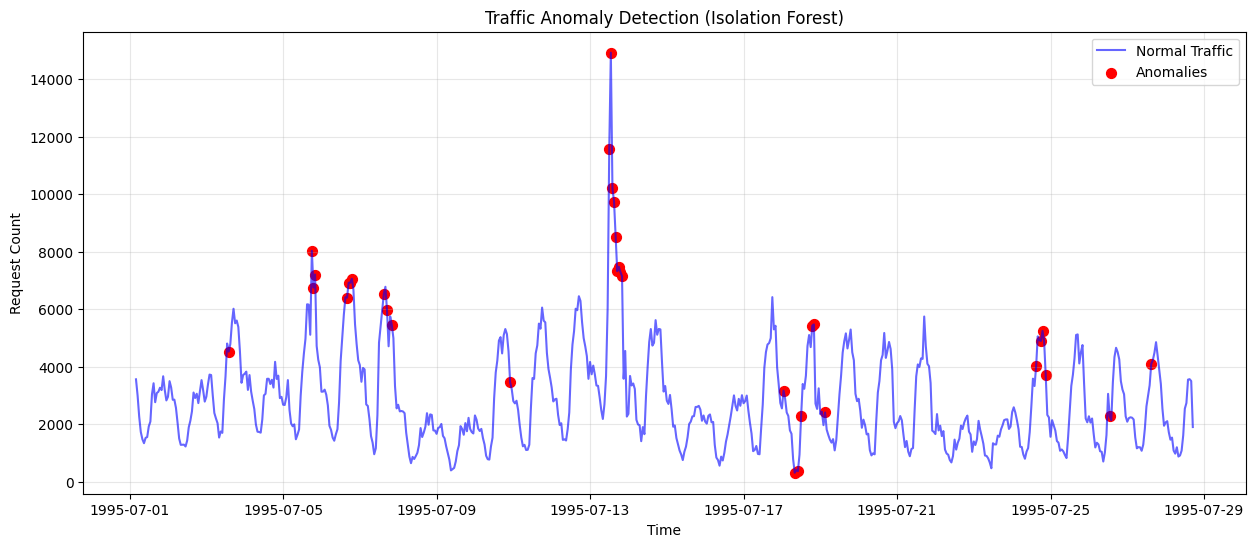

: 

In [ ]:
result_anomaly = run_anomaly_detection(raw_data)

In [ ]:
best_xgb, best_gbr = run_tuned_comparison(raw_data)

                           request_count  error_5xx  bytes_sum   lag_1  \
timestamp                                                                
1995-07-01 06:00:00+00:00           2268          0   57160621  3004.0   
1995-07-01 07:00:00+00:00           1734          0   37293218  2268.0   
1995-07-01 08:00:00+00:00           1482          0   29319770  1734.0   
1995-07-01 09:00:00+00:00           1343          0   33093160  1482.0   
1995-07-01 10:00:00+00:00           1528          0   37588204  1343.0   
...                                  ...        ...        ...     ...   
1995-07-28 12:00:00+00:00           2543          0   54578535  1616.0   
1995-07-28 13:00:00+00:00           2741          0   50517235  2543.0   
1995-07-28 14:00:00+00:00           3555          0   64336150  2741.0   
1995-07-28 15:00:00+00:00           3570          0   53777526  3555.0   
1995-07-28 16:00:00+00:00           3505          0   56494872  3570.0   

                            lag_2    

In [ ]:
# Save Model
import joblib

joblib.dump(result_anomaly[0], "./model/anomaly_model.pkl")
joblib.dump(best_xgb, "./model/best_xgb.pkl")
joblib.dump(best_gbr, "./model/best_gbr.pkl")

NameError: name 'result_anomaly' is not defined